In [1]:
from neuromaps import NeuroMapOriginal, NeuroMapTargetNormalized

model_original = NeuroMapOriginal.load("checkpoints/original/model.ckpt")
fixed_model = NeuroMapTargetNormalized.load("checkpoints/fixed/model.ckpt")

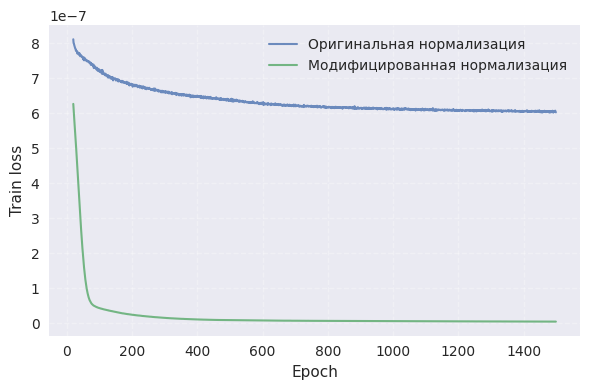

In [6]:
import matplotlib.pyplot as plt
import numpy as np

pass_first = 20
hist_o = model_original.training_history["train_loss"][pass_first:]
hist_f = fixed_model.training_history["train_loss"][pass_first:]

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

epochs_o = np.arange(pass_first, pass_first + len(hist_o))
epochs_f = np.arange(pass_first, pass_first + len(hist_f))

ax.plot(epochs_o, hist_o,
        label="Оригинальная нормализация", lw=1.5, alpha=.8)
ax.plot(epochs_f, hist_f,
        label="Модифицированная нормализация", lw=1.5, alpha=.8)

ax.set_xlabel("Epoch")
ax.set_ylabel("Train loss")
ax.legend()
ax.grid(True, ls="--", alpha=.3)
plt.tight_layout()
plt.show()

In [7]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import chua_rk4, chua_right_part

u0 = [-3.43086445, -1.78514213, -4.73140597]
p = [8.4, 12, 0, -0.12, -1.15]

nm_orig_traj = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
nm_modf_traj = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)
ode_traj = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 50, 50, lambda x, y: x[1], lambda x, y: [0, 1], divergence_threshold=1e3)

if nm_orig_traj is not None:
    nm_orig_traj = nm_orig_traj[10000:]
if nm_modf_traj is not None:
    nm_modf_traj = nm_modf_traj[10000:]

plot_compare_trajectories(ode_traj, nm_orig_traj, nm_modf_traj, labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'],
layout='sidebyside')

Симуляция:   0%|▏                                              | 85/20000 [00:00<00:23, 849.49шаг/s]

2026-01-11 18:52:31 - neuromap_sync.nm_original - INFO - simulate:249 - Траектория разошлась (норма = 1.00e+03 > 1.00e+03)


Симуляция:   6%|██▌                                        | 1182/20000 [00:00<00:01, 11816.60шаг/s]

2026-01-11 18:52:31 - neuromap_sync.nm_target_normalized - INFO - simulate:258 - Траектория разошлась (норма = 1.00e+03 > 1.00e+03)


Симуляция:   6%|██▋                                        | 1274/20000 [00:00<00:01, 11535.45шаг/s]

2026-01-11 18:52:31 - neuromap_sync.plots - WARNING - plot_compare_trajectories:182 - Все траектории пустые или None


Симуляция: 100%|██████████████████████████████████████████| 50000/50000 [00:04<00:00, 11978.54шаг/s]


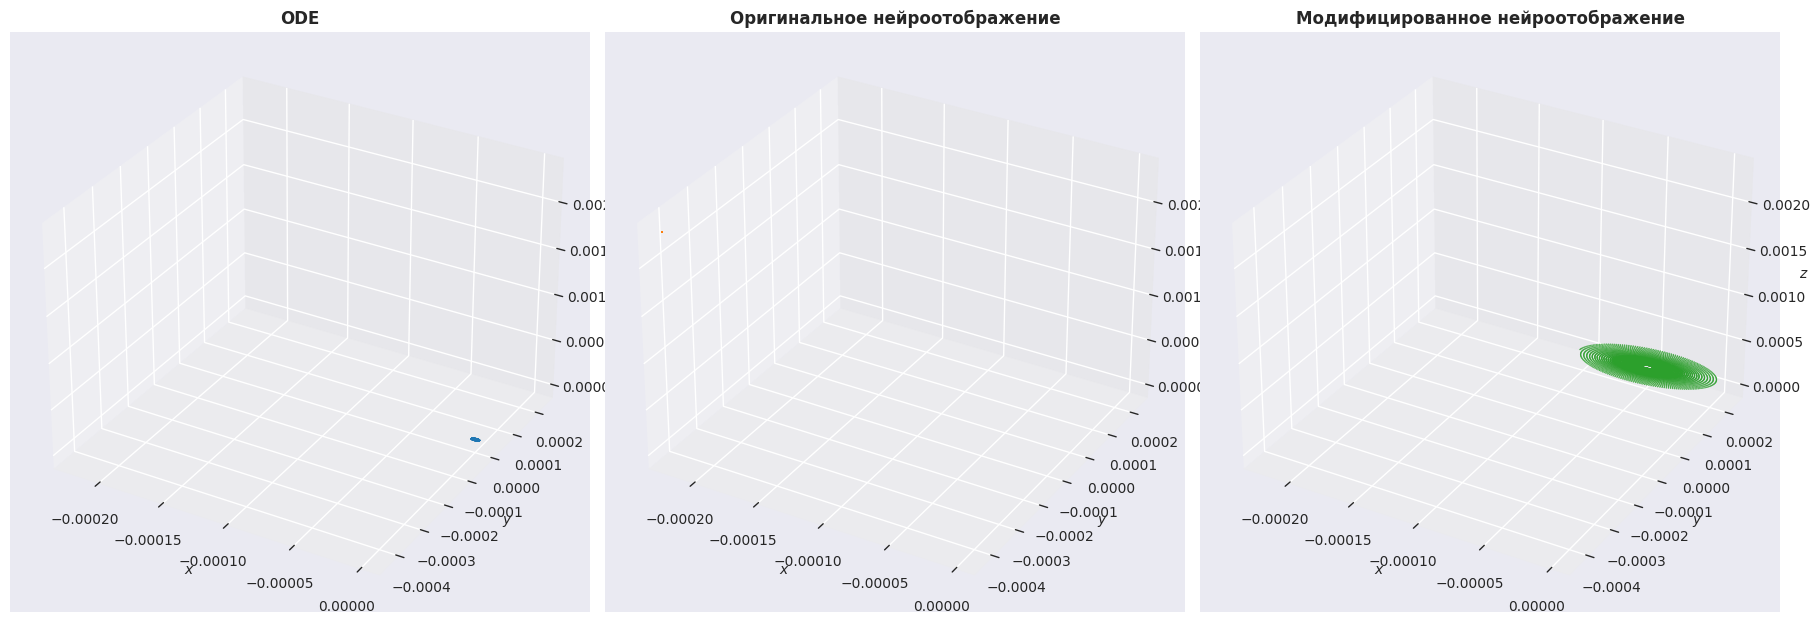

In [14]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import chua_rk4, chua_right_part

u0 = [-3.91055058, 1.14827257, 4.0497644]
p = [8.4, 12, 0, -0.12, -1.15]

nm_orig_traj = model_original.simulate(u0=u0, p=p, n_steps=50000, divergence_threshold=1e4)
nm_modf_traj = fixed_model.simulate(u0=u0, p=p, n_steps=50000, divergence_threshold=1e4)
ode_traj = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 300, 100, lambda x, y: x[1], lambda x, y: [0, 1, 0], divergence_threshold=1e4)

if nm_orig_traj is not None:
    nm_orig_traj = nm_orig_traj[40000:]
if nm_modf_traj is not None:
    nm_modf_traj = nm_modf_traj[40000:]

plot_compare_trajectories(ode_traj, nm_orig_traj, nm_modf_traj, labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'],
layout='sidebyside')

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:01<00:00, 12243.71шаг/s]


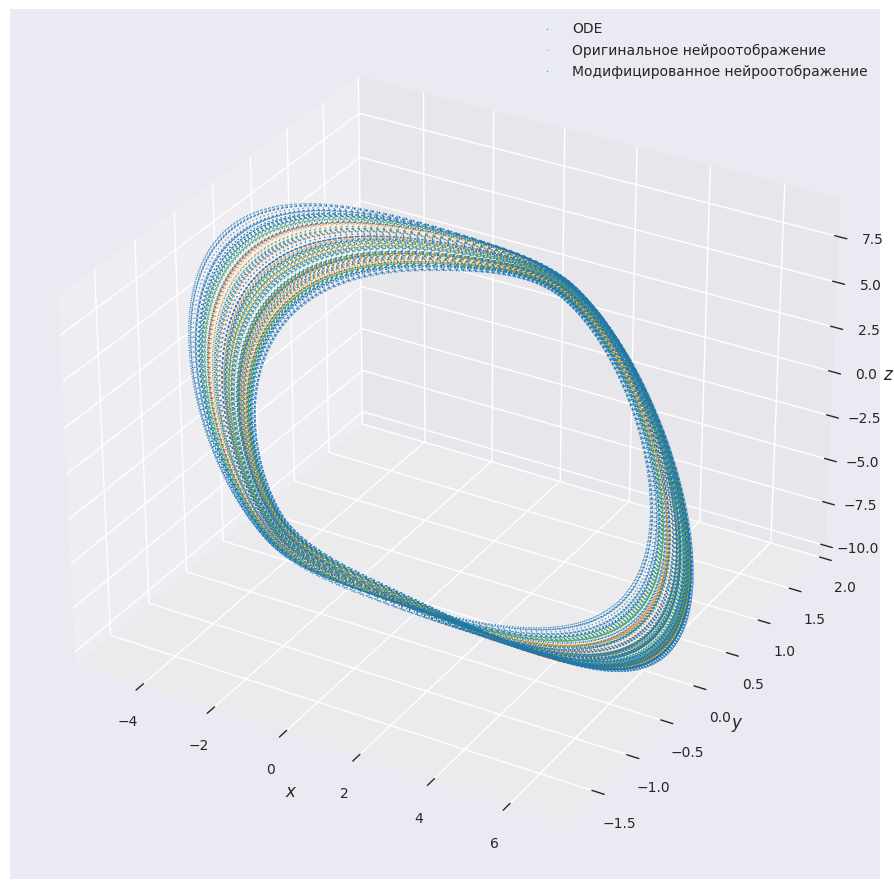

In [12]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import chua_rk4, chua_right_part

u0 = [-0.06298417, -1.53119096, 2.58772816]
p = [8.4, 12, 0, -0.12, -1.15]

nm_orig_traj1 = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
nm_modf_traj1 = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
ode_traj = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 100, 100, lambda x, y: x[1], lambda x, y: [0, 1, 0], divergence_threshold=1e4)

if nm_orig_traj1 is not None:
    nm_orig_traj1 = nm_orig_traj1[10000:]
if nm_modf_traj1 is not None:
    nm_modf_traj1 = nm_modf_traj1[10000:]

plot_compare_trajectories(ode_traj, nm_orig_traj1, nm_modf_traj1, labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'])

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:01<00:00, 12841.32шаг/s]


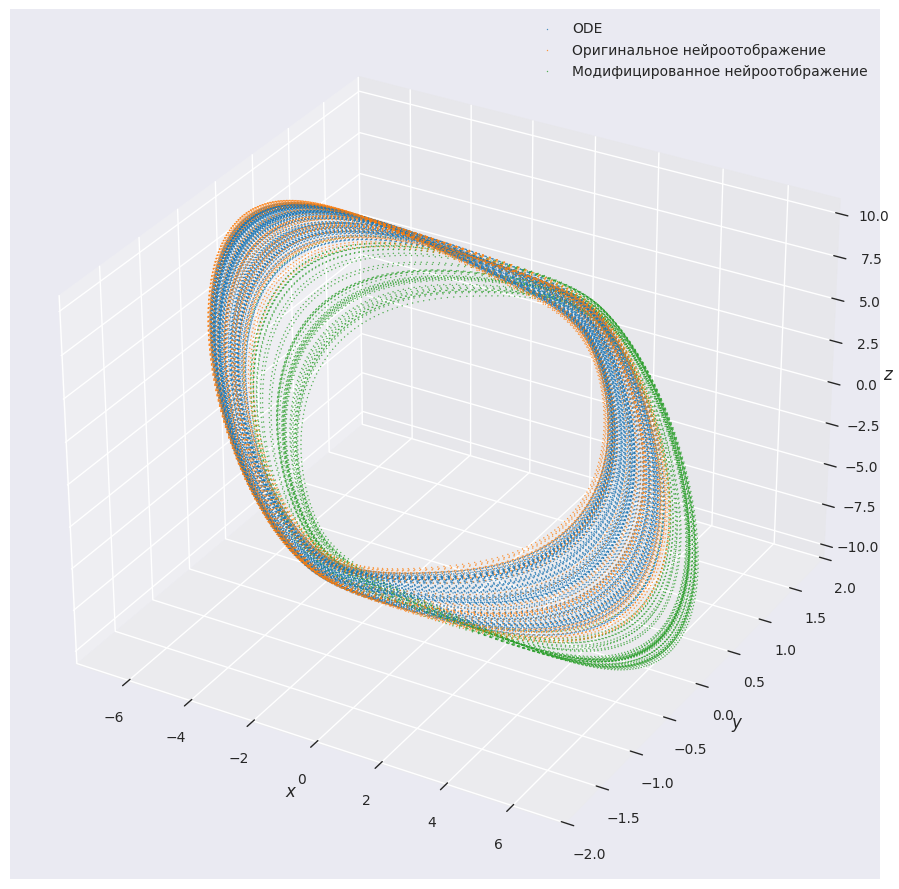

In [11]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import chua_rk4, chua_right_part

u0 = [ 2.98994669e+00, 4.49008896e-04, -4.52306348e+00]
p = [8.4, 12, 0, -0.12, -1.15]

nm_orig_traj2 = model_original.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
nm_modf_traj2 = fixed_model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e4)
ode_traj = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 300, 100, lambda x, y: x[1], lambda x, y: [0, 1, 0], divergence_threshold=1e4)

if nm_orig_traj2 is not None:
    nm_orig_traj2 = nm_orig_traj2[10000:]
if nm_modf_traj2 is not None:
    nm_modf_traj2 = nm_modf_traj2[10000:]

plot_compare_trajectories(ode_traj, nm_orig_traj2, nm_modf_traj2,
    labels=['ODE', 'Оригинальное нейроотображение', 'Модифицированное нейроотображение'])

In [17]:
import numpy as np
from tqdm import tqdm

p = [8.4, 12, 0, -0.12, -1.15]
n_trajectories = 1000
n_steps = 20000
divergence_threshold = 1e4

np.random.seed(52)
initial_conditions = []
for _ in range(n_trajectories):
    u0 = [np.random.uniform(-15, 15), np.random.uniform(-4, 4), np.random.uniform(-18, 18)]
    initial_conditions.append(u0)

none_count_original = 0
none_count_fixed = 0
none_count_ode = 0

print(f"Тестирование {n_trajectories} траекторий...")

for i, u0 in enumerate(tqdm(initial_conditions, desc="Обработка траекторий")):
    traj_orig = model_original.simulate(u0=u0, p=p, n_steps=n_steps, divergence_threshold=divergence_threshold)
    if traj_orig is None:
        none_count_original += 1
    
    traj_fixed = fixed_model.simulate(u0=u0, p=p, n_steps=n_steps, divergence_threshold=divergence_threshold)
    if traj_fixed is None:
        none_count_fixed += 1
    
    traj_ode = get_attractor_trajectory(chua_rk4, chua_right_part, u0, p, 0.01, 200, 100, 
                                       lambda x, y: x[1], lambda x, y: [0, 1, 0], 
                                       divergence_threshold=divergence_threshold)
    if traj_ode is None:
        none_count_ode += 1

escape_rate_original = none_count_original / n_trajectories
escape_rate_fixed = none_count_fixed / n_trajectories
escape_rate_ode = none_count_ode / n_trajectories

Тестирование 1000 траекторий...


Обработка траекторий:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-01-11 22:54:01 - neuromap_sync.nm_original - INFO - simulate:249 - Траектория разошлась (норма = 1.00e+04 > 1.00e+04)


Симуляция:  26%|███████████▍                                | 5187/20000 [00:00<00:01, 9483.87шаг/s]


2026-01-11 22:54:01 - neuromap_sync.nm_target_normalized - INFO - simulate:258 - Траектория разошлась (норма = 1.00e+04 > 1.00e+04)


...

2026-01-11 23:21:42 - neuromap_sync.nm_original - INFO - simulate:249 - Траектория разошлась (норма = 1.00e+04 > 1.00e+04)


Симуляция:  25%|██████████▊                                | 5022/20000 [00:00<00:01, 10629.33шаг/s]


2026-01-11 23:21:43 - neuromap_sync.nm_target_normalized - INFO - simulate:258 - Траектория разошлась (норма = 1.00e+04 > 1.00e+04)


Обработка траекторий: 100%|██████████| 1000/1000 [27:43<00:00,  1.66s/it]


=== РЕЗУЛЬТАТЫ АНАЛИЗА ДОЛЕЙ УБЕГАНИЯ ===
Общее количество траекторий: 1000

Оригинальная модель:
  Убежавших траекторий: 904
  Доля убегания: 0.904 (90.4%)

Модифицированная модель:
  Убежавших траекторий: 903
  Доля убегания: 0.903 (90.3%)

ODE решение:
  Убежавших траекторий: 903
  Доля убегания: 0.903 (90.3%)

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
Модифицированная модель показывает улучшение на 0.1% по сравнению с оригинальной

Относительно ODE решения:
  Оригинальная модель: разница 0.1%
  Модифицированная модель: разница 0.0%


In [18]:
print("\n=== РЕЗУЛЬТАТЫ АНАЛИЗА ДОЛЕЙ УБЕГАНИЯ ===")
print(f"Общее количество траекторий: {n_trajectories}")
print(f"\nОригинальная модель:")
print(f"  Убежавших траекторий: {none_count_original}")
print(f"  Доля убегания: {escape_rate_original:.3f} ({escape_rate_original*100:.1f}%)")
print(f"\nМодифицированная модель:")
print(f"  Убежавших траекторий: {none_count_fixed}")
print(f"  Доля убегания: {escape_rate_fixed:.3f} ({escape_rate_fixed*100:.1f}%)")
print(f"\nODE решение:")
print(f"  Убежавших траекторий: {none_count_ode}")
print(f"  Доля убегания: {escape_rate_ode:.3f} ({escape_rate_ode*100:.1f}%)")

print(f"\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
if escape_rate_fixed < escape_rate_original:
    improvement = (escape_rate_original - escape_rate_fixed) / escape_rate_original * 100
    print(f"Модифицированная модель показывает улучшение на {improvement:.1f}% по сравнению с оригинальной")
elif escape_rate_fixed > escape_rate_original:
    degradation = (escape_rate_fixed - escape_rate_original) / escape_rate_original * 100
    print(f"Модифицированная модель показывает ухудшение на {degradation:.1f}% по сравнению с оригинальной")
else:
    print("Модифицированная и оригинальная модели показывают одинаковые результаты")

print(f"\nОтносительно ODE решения:")
print(f"  Оригинальная модель: разница {abs(escape_rate_original - escape_rate_ode)*100:.1f}%")
print(f"  Модифицированная модель: разница {abs(escape_rate_fixed - escape_rate_ode)*100:.1f}%")


=== РЕЗУЛЬТАТЫ АНАЛИЗА ДОЛЕЙ УБЕГАНИЯ ===
Общее количество траекторий: 1000

Оригинальная модель:
  Убежавших траекторий: 904
  Доля убегания: 0.904 (90.4%)

Модифицированная модель:
  Убежавших траекторий: 903
  Доля убегания: 0.903 (90.3%)

ODE решение:
  Убежавших траекторий: 903
  Доля убегания: 0.903 (90.3%)

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
Модифицированная модель показывает улучшение на 0.1% по сравнению с оригинальной

Относительно ODE решения:
  Оригинальная модель: разница 0.1%
  Модифицированная модель: разница 0.0%
